Resample point of streamline and of MAS to be on a uniform grid with a given number of point

In [1]:
import numpy as np
import pandas
from coloraide import Color
import matplotlib.pylab as pl
import ot
import scipy as sc

In [35]:
import sys
sys.path.append('../script/')
from plot_GMM import draw_iso_MAP,draw_aniso_MAP
from from_pandas_to_numpy import pandas_to_numpy_tract,pandas_to_numpy_tract_interpolate,pandas_to_numpy_MAT,pandas_to_numpy_MAT_interpolate
from ICP import ICP_tracts
from clustering import clustering_MASs,clustering_tract
from utils import compute_ksize

# Plot streamlines

In [3]:
subject = 599469
tract = 'CST_left'
tract = pandas.read_csv('/home/gui/Documents/Post-doc/data/HCP_105/'+str(subject)+'/06-AlignedTracts/csv/'+tract+'_aligned.csv')
m1,nb_pts1=pandas_to_numpy_tract(tract,nb_streamline=20)

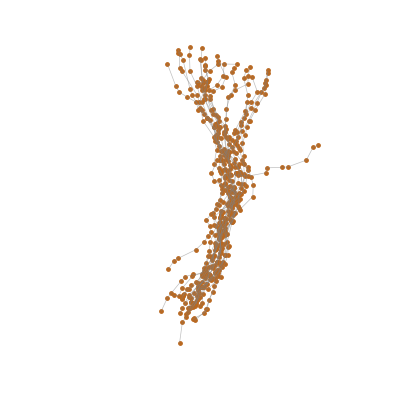

In [4]:
s=6e0
axis=(0,2)
color = '#B96820'
pl.figure(figsize=(5,5))
for i in range(len(nb_pts1)):
    for j in range(nb_pts1[i]):
        pl.scatter(m1[i][j,axis[0]], m1[i][j,axis[1]],color=color,s=s)
    pl.plot(m1[i][:,axis[0]], m1[i][:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Powerspeech/figures/streamline.pdf",bbox_inches='tight')

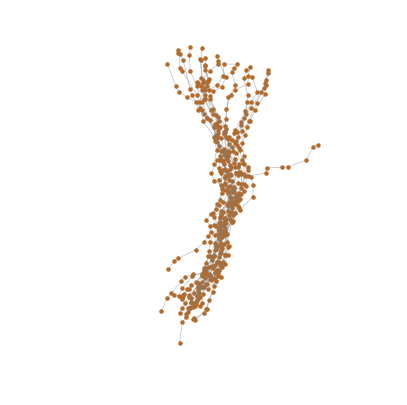

In [5]:
s=5e0
axis=(0,2)
color = '#B96820'
pl.figure(figsize=(5,5))
for i in range(len(nb_pts1)):
    for j in range(nb_pts1[i]):
        pl.scatter(m1[i][j,axis[0]], m1[i][j,axis[1]],color=color,s=s)
    pl.plot(m1[i][:,axis[0]], m1[i][:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/addmcm/streamline.pdf",bbox_inches='tight')

# plot MAS

In [6]:
subject = 599469
tract = 'CST_left'
tract_MCM = pandas.read_csv('/home/gui/Documents/Post-doc/data/HCP_105/'+str(subject)+'/07-AugmentedTractsOT/'+tract+'_avg_aligned_ordered.csv')
d=3

In [7]:
m1,wI1,I1,w1,S1,nb_MAP1=pandas_to_numpy_MAT(tract_MCM,nb_MAS=20)

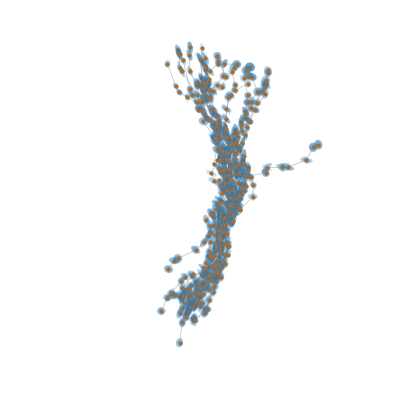

In [8]:
s=3e0
axis=(0,2)
s_aniso=6*[50]
s_iso=50
color1='C0'
color2='#B96820'

pl.figure(figsize=(5,5))
for i in range(len(nb_MAP1)):
    for j in range(nb_MAP1[i]):
        draw_iso_MAP(m1[i][j],wI1[i][j],I1[i][j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)
        draw_aniso_MAP(m1[i][j],w1[i][j],S1[i][j], color=color1, alpha=1,s=s,s_aniso=s_aniso,axis=axis,color_scatter=color2)
    pl.plot(m1[i][:,axis[0]], m1[i][:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/addmcm/MAS.pdf",bbox_inches='tight')

# Resample 

In [9]:
subject = 599469
tract = 'CST_left'
tract_MCM = pandas.read_csv('/home/gui/Documents/Post-doc/data/HCP_105/'+str(subject)+'/07-AugmentedTractsOT/'+tract+'_avg_aligned_ordered.csv')
d=3

i=6
m1,wI1,I1,w1,S1,nb_MAP1=pandas_to_numpy_MAT(tract_MCM,nb_MAS=1,streamlineId=[i])
m2,wI2,I2,w2,S2,nb_MAP2=pandas_to_numpy_MAT_interpolate(tract_MCM,nb_MAS=1,nb_MAP=20,streamlineId=[i])

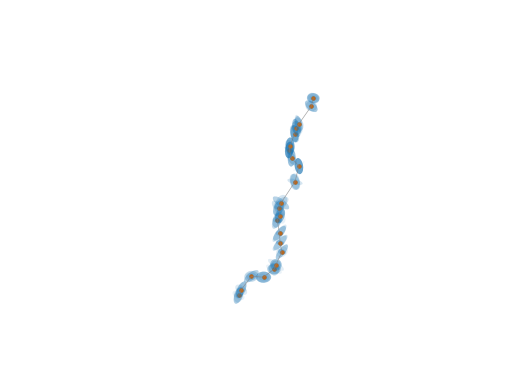

In [10]:
s=4e0
axis=(0,2)
s_aniso=6*[70]
s_iso=50
color1='C0'
color2='#B96820'

for j in range(nb_MAP1):
    draw_iso_MAP(m1[j],wI1[j],I1[j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)
    draw_aniso_MAP(m1[j],w1[j],S1[j], color=color1, alpha=1,s=s,s_aniso=s_aniso,axis=axis,color_scatter=color2)
pl.plot(m1[:,axis[0]], m1[:,axis[1]],linewidth=.5,color='grey',alpha=.7)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/resample/old_grid.pdf",bbox_inches='tight')

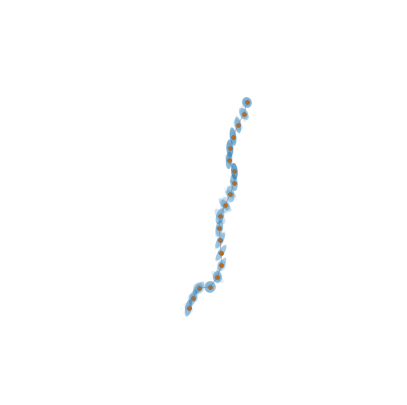

In [11]:
pl.figure(figsize=(5,5))
for j in range(nb_MAP2):
    draw_iso_MAP(m2[j],wI2[j],I2[j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)
    draw_aniso_MAP(m2[j],w2[j],S2[j], color=color1, alpha=1,s=s,s_aniso=s_aniso,axis=axis,color_scatter=color2)
pl.plot(m2[:,axis[0]], m2[:,axis[1]],linewidth=.5,color='grey',alpha=.7)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/resample/new_grid.pdf",bbox_inches='tight')

# Clustering 1

In [13]:
subject = 599469
tract = 'CST_left'
tract_MCM = pandas.read_csv('/home/gui/Documents/Post-doc/data/HCP_105/'+str(subject)+'/07-AugmentedTractsOT/'+tract+'_avg_aligned_ordered.csv')
d=3

nb_MAS=20
nb_MAP=20
streamlineId=np.arange(nb_MAS*0+1,nb_MAS*2)
m1,wI1,I1,w1,S1,nb_MAP1=pandas_to_numpy_MAT_interpolate(tract_MCM,nb_MAS=nb_MAS,nb_MAP=nb_MAP,streamlineId=streamlineId)

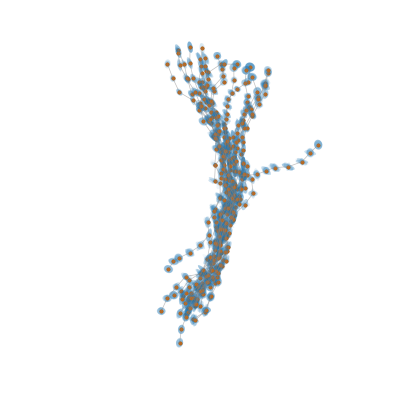

In [14]:
s=3e0
axis=(0,2)
s_aniso=6*[50]
s_iso=50
color1='C0'
color2='#B96820'

pl.figure(figsize=(5,5))
for i in range(nb_MAS):
    for j in range(nb_MAP):
        draw_iso_MAP(m1[i,j],wI1[i,j],I1[i,j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)
        draw_aniso_MAP(m1[i,j],w1[i,j],S1[i,j], color=color1, alpha=1,s=s,s_aniso=s_aniso,axis=axis,color_scatter=color2)
    pl.plot(m1[i][:,axis[0]], m1[i][:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/clustering/source1.pdf",bbox_inches='tight')

In [15]:
nb_r=7
m2,wI2,I2,w2,S2,_,_=clustering_MASs(nb_r,m1,wI1,I1,w1,S1,itr=20,eps=1e-7)

0 1 2 3 

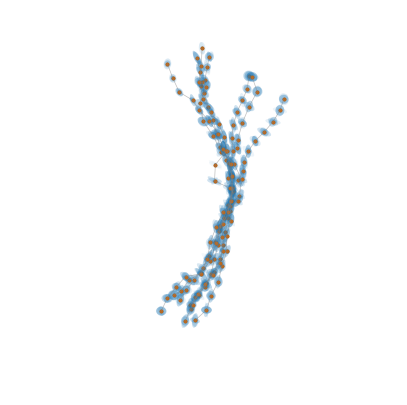

In [16]:
s=3e0
axis=(0,2)
s_aniso=6*[60]
s_iso=60
color1='C0'
color2='#B96820'

pl.figure(figsize=(5,5))
for i in range(nb_r):
    for j in range(nb_MAP):
        draw_iso_MAP(m2[i,j],wI2[i,j],I2[i,j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)
        draw_aniso_MAP(m2[i,j],w2[i,j],S2[i,j], color=color1, alpha=1,s=s,s_aniso=s_aniso,axis=axis,color_scatter=color2)
    pl.plot(m2[i][:,axis[0]], m2[i][:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/clustering/Centroid1.pdf",bbox_inches='tight')

# Clustering 2

In [27]:
subject = 599469
tract = 'CST_left'
tract_MCM = pandas.read_csv('/home/gui/Documents/Post-doc/data/HCP_105/'+str(subject)+'/07-AugmentedTractsOT/'+tract+'_avg_aligned_ordered.csv')
d=3

nb_MAS=20
nb_MAP=20
streamlineId=np.arange(nb_MAS*2+1,nb_MAS*3+1)
m1,wI1,I1,w1,S1,nb_pts1=pandas_to_numpy_MAT_interpolate(tract_MCM,nb_MAS=nb_MAS,nb_MAP=nb_MAP,streamlineId=streamlineId)

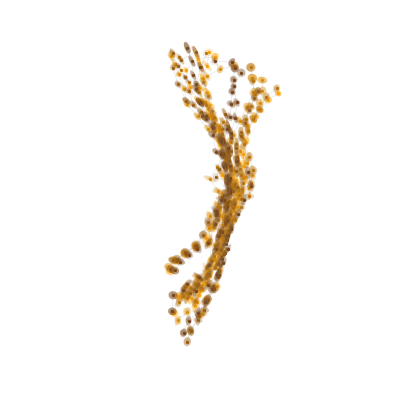

In [29]:
s=1e0
axis=(0,2)
s_aniso=6*[50]
s_iso=50

cmap = Color.interpolate(['orange', "#774315"],space='srgb')

pl.figure(figsize=(5,5))
for i in range(nb_MAS):
    if i<4:
        color=cmap(0)
    if i>=4 and i<8:
        color=cmap(.25)
    if i>=8 and i<12:
        color=cmap(0.5)
    if i>=12 and i<16:
        color=cmap(0.75)
    if i>=16:
        color=cmap(1)
        
    for j in range(nb_MAP):
        draw_iso_MAP(m1[i,j],wI1[i,j],I1[i,j], color=color, alpha=1,s=s,s_iso=s_iso,axis=axis)
        draw_aniso_MAP(m1[i,j],w1[i,j],S1[i,j], color=color, alpha=1,s=s,s_aniso=s_aniso,axis=axis)
    pl.plot(m1[i][:,axis[0]], m1[i][:,axis[1]],linewidth=.5,color='grey',alpha=.2)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/clustering/source2.pdf",bbox_inches='tight')

In [30]:
nb_r=16
m2,wI2,I2,w2,S2,_,_=clustering_MASs(nb_r,m1,wI1,I1,w1,S1,itr=20,eps=1e-7)

0 1 2 

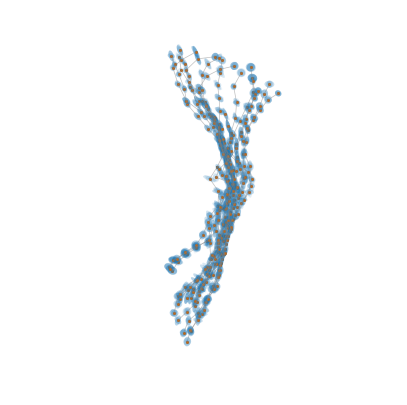

In [31]:
s=1e0
axis=(0,2)
s_aniso=6*[50]
s_iso=50
color1='C0'
color2="#B96820"

pl.figure(figsize=(5,5))
for i in range(nb_r):
    for j in range(nb_MAP):
        draw_iso_MAP(m2[i,j],wI2[i,j],I2[i,j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)
        draw_aniso_MAP(m2[i,j],w2[i,j],S2[i,j], color=color1, alpha=1,s=s,s_aniso=s_aniso,axis=axis,color_scatter=color2)
    pl.plot(m2[i][:,axis[0]], m2[i][:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/clustering/Centroid2.pdf",bbox_inches='tight')

# Cluster 3

In [13]:
subject = 599469
tract = 'CST_left'
tract_MCM = pandas.read_csv('/home/gui/Documents/Post-doc/data/HCP_105/'+str(subject)+'/07-AugmentedTractsOT/'+tract+'_avg_aligned_ordered.csv')
d=3

nb_MAS=20
nb_MAP=20
streamlineId=np.arange(nb_MAS*0+1,nb_MAS*2)
m1,_,_,_,_,nb_MAP1=pandas_to_numpy_MAT_interpolate(tract_MCM,nb_MAS=nb_MAS,nb_MAP=nb_MAP,streamlineId=streamlineId)

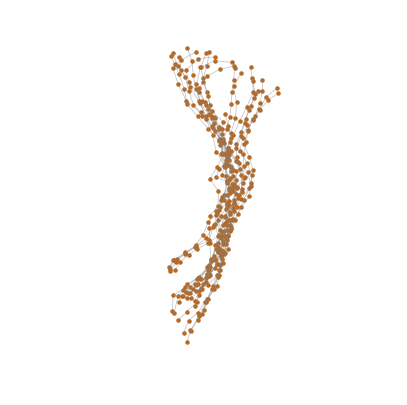

In [40]:
s=5e0
axis=(0,2)
s_aniso=6*[50]
s_iso=50
color1='C0'
color2='#B96820'

pl.figure(figsize=(5,5))
for i in range(nb_MAS):
    for j in range(nb_MAP):
        pl.scatter(m1[i,j,axis[0]],m1[i,j,axis[1]],color=color2,s=s)
    pl.plot(m1[i][:,axis[0]], m1[i][:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster_simplified/figures/encart/clustering/source1.pdf",bbox_inches='tight')

In [41]:
nb_r=7
m2,_,_=clustering_tract(nb_r,m1,itr=20,eps=1e-7)

0 1 2 

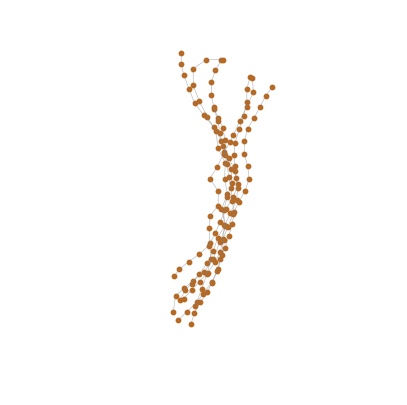

In [42]:
s=1e1
axis=(0,2)
s_aniso=6*[50]
s_iso=50
color1='C0'
color2='#B96820'

pl.figure(figsize=(5,5))
for i in range(nb_r):
    for j in range(nb_MAP):
        pl.scatter(m2[i,j,axis[0]],m2[i,j,axis[1]],color=color2,s=s)
    pl.plot(m2[i][:,axis[0]], m2[i][:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-40,-40,110
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster_simplified/figures/encart/clustering/Centroid1.pdf",bbox_inches='tight')

# Alignment

In [20]:
subject = 599469
tract = 'CST_left'

tract = pandas.read_csv('/home/gui/Documents/Post-doc/data/HCP_105/'+str(subject)+'/06-AlignedTracts/csv/'+tract+'_aligned_ordered.csv')

nb_streamline=20
n=40
m=[]
theta=[0,np.pi/4,-np.pi/4,np.pi/2,-np.pi/3]
nb_pts=20
np.random.seed(0)
for i in range(5):
    R=np.zeros((3,3))
    R[0,0]=np.cos(theta[i])
    R[2,2]=np.cos(theta[i])
    R[0,2]=-np.sin(theta[i])
    R[2,0]=np.sin(theta[i])
    
    idx=np.arange(nb_streamline*i+1,nb_streamline*(i+1)+1)
    mu=from_tract_to_numpy_interpolate(tract,nb_streamline,nb_pts,streamlineId=idx)[0]
    mu-=mu.mean()
    mu+=mu@R
    m+=[mu]

/tmp/ipykernel_51632/2424774751.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  pl.scatter(m[i][j,:,axis[0]], m[i][j,:,axis[1]], c=color,s=s)


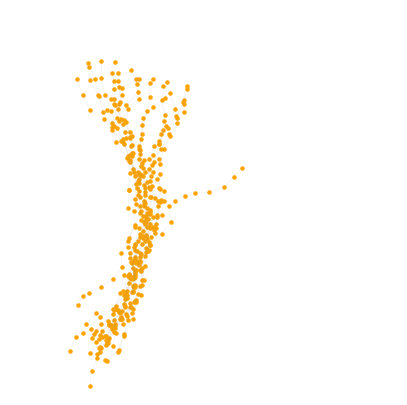

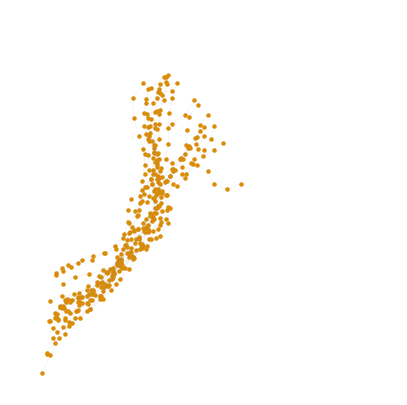

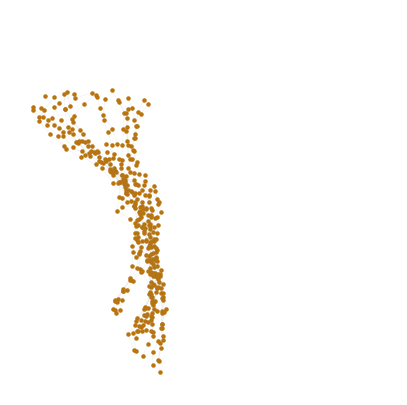

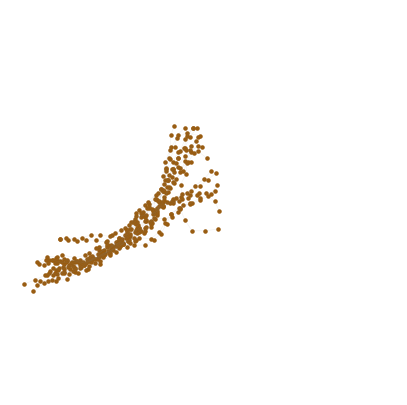

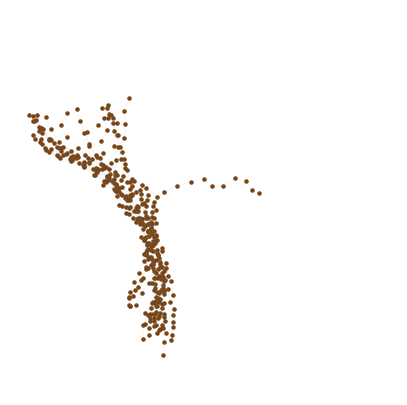

In [21]:
cmap = Color.interpolate(['orange', "#774315"],space='srgb')

s=5e0
axis=(0,2)
for i in range(5):
    color=cmap(i/4)
    pl.figure(figsize=(5,5))
    for j in range(nb_streamline):
        pl.scatter(m[i][j,:,axis[0]], m[i][j,:,axis[1]], c=color,s=s)
        pl.plot(m[i][j,:,axis[0]], m[i][j,:,axis[1]],linewidth=.5,color='grey',alpha=.1)
    xmin,ymin,sq=-60,-90,200
    pl.xlim(xmin,xmin+sq)
    pl.ylim(ymin,ymin+sq)
    pl.axis("off")
    pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/alignment/source"+str(i)+".pdf",bbox_inches='tight')   

In [22]:
m11_l=[]
for i in range(1,5):
    reflexion=False
    lam1,lam2=0,0

    m11,m22,R,t,sigma=ICP_tracts(m[i],m[0],reflexion,lam1,lam2,itr=5)
    m11_l+=[m11]

/tmp/ipykernel_51632/3555645506.py:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  pl.scatter(m[0][j,:,axis[0]], m[0][j,:,axis[1]], c=color,s=s)
/tmp/ipykernel_51632/3555645506.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  pl.scatter(m11_l[i][j,:,axis[0]], m11_l[i][j,:,axis[1]], c=color,s=s)


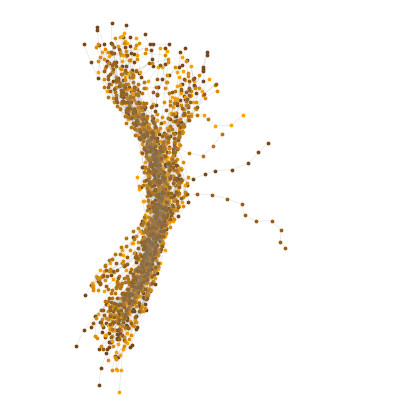

In [23]:
cmap = Color.interpolate(['orange', "#774315"],space='srgb')
s=3e0
axis=(0,2)
pl.figure(figsize=(5,5))
color=cmap(1)
for j in range(nb_streamline):
    pl.scatter(m[0][j,:,axis[0]], m[0][j,:,axis[1]], c=color,s=s)
    pl.plot(m[0][j,:,axis[0]], m[0][j,:,axis[1]],linewidth=.5,color='grey',alpha=.2)
    
for i in range(0,4):
    color=cmap(i/4)
    for j in range(nb_streamline):
        pl.scatter(m11_l[i][j,:,axis[0]], m11_l[i][j,:,axis[1]], c=color,s=s)
        pl.plot(m11_l[i][j,:,axis[0]], m11_l[i][j,:,axis[1]],linewidth=.5,color='grey',alpha=.2)
        
xmin,ymin,sq=-60,-90,180
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/encart/alignment/target.pdf",bbox_inches='tight')   

# Build fake Atlas

In [24]:
"""subject = 599469
tract = 'CST_left'
tract_MCM1 = pandas.read_csv('/home/gui/Documents/Post-doc/data/TracksMCMOT/'+str(subject)+'/csv/centroid/CST_left_avg_fake.csv')
tract_MCM2= pandas.read_csv('/home/gui/Documents/Post-doc/data/TracksMCMOT/'+str(subject)+'/csv/centroid/CST_right_avg_fake.csv')
d=3
nb_streamline=16
ksize1=compute_ksize(tract_MCM1)
ksize2=compute_ksize(tract_MCM2)

m1,wI1,I1,w1,S1,nb_pts1=from_tractMCM_to_numpy(tract_MCM1,nb_streamline=nb_streamline)
m2,wI2,I2,w2,S2,nb_pts2=from_tractMCM_to_numpy(tract_MCM2,nb_streamline=nb_streamline)
s=1e0
axis=(0,2)
s_aniso1=ksize1*[60]
s_aniso2=ksize2*[60]
s_iso=40
color1='C0'
color2="#B96820"

pl.figure(figsize=(5,5))
for i in range(len(nb_pts1)):
    for j in range(nb_pts1[i]):
        draw_iso_streamline(m1[i][j],wI1[i][j],I1[i][j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)
        draw_aniso_streamline(m1[i][j],w1[i][j],S1[i][j], color=color1, alpha=1,s=s,s_aniso=s_aniso1,axis=axis,color_scatter=color2)
    pl.plot(m1[i][:,axis[0]], m1[i][:,axis[1]],linewidth=.5,color='grey',alpha=.4)
    
for i in range(len(nb_pts2)):
    for j in range(nb_pts2[i]):
        draw_iso_streamline(m2[i][j],wI2[i][j],I2[i][j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)
        draw_aniso_streamline(m2[i][j],w2[i][j],S2[i][j], color=color1, alpha=1,s=s,s_aniso=s_aniso2,axis=axis,color_scatter=color2)
    pl.plot(m2[i][:,axis[0]], m2[i][:,axis[1]],linewidth=.5,color='grey',alpha=.4)

    
xmin,ymin,sq=-55,-60,125
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)
pl.axis("off")
pl.savefig("/home/gui/Documents/Post-doc/Papier/IST2025/Poster/figures/results/atlas.pdf",bbox_inches='tight')"""

'subject = 599469\ntract = \'CST_left\'\ntract_MCM1 = pandas.read_csv(\'/home/gui/Documents/Post-doc/data/TracksMCMOT/\'+str(subject)+\'/csv/centroid/CST_left_avg_fake.csv\')\ntract_MCM2= pandas.read_csv(\'/home/gui/Documents/Post-doc/data/TracksMCMOT/\'+str(subject)+\'/csv/centroid/CST_right_avg_fake.csv\')\nd=3\nnb_streamline=16\nksize1=compute_ksize(tract_MCM1)\nksize2=compute_ksize(tract_MCM2)\n\nm1,wI1,I1,w1,S1,nb_pts1=from_tractMCM_to_numpy(tract_MCM1,nb_streamline=nb_streamline)\nm2,wI2,I2,w2,S2,nb_pts2=from_tractMCM_to_numpy(tract_MCM2,nb_streamline=nb_streamline)\ns=1e0\naxis=(0,2)\ns_aniso1=ksize1*[60]\ns_aniso2=ksize2*[60]\ns_iso=40\ncolor1=\'C0\'\ncolor2="#B96820"\n\npl.figure(figsize=(5,5))\nfor i in range(len(nb_pts1)):\n    for j in range(nb_pts1[i]):\n        draw_iso_streamline(m1[i][j],wI1[i][j],I1[i][j], color=color1, alpha=1,s=s,s_iso=s_iso,axis=axis,color_scatter=color2)\n        draw_aniso_streamline(m1[i][j],w1[i][j],S1[i][j], color=color1, alpha=1,s=s,s_aniso=s_

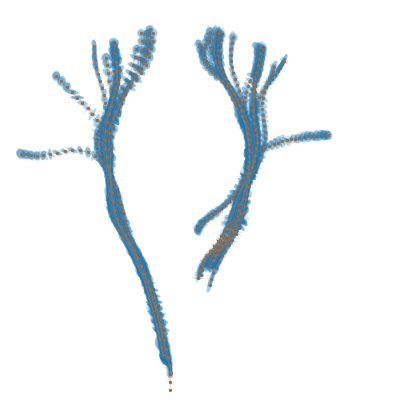